# Modelo Random Forest

In [1]:
## CARGA DE LIBRERIAS ##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import pickle

In [2]:
## CARGA DE DATASET ##
df = pd.read_csv('~/Documents/Universidad/TFM/TFM_imarcospu/Dataset/dataset_sdn.csv') 
# Observamos los primeros datos
df.head(5)

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0


In [3]:
# filtramos datos de tot_kbps 
df = df[df['label'] == 0]

# eliminamos columna switch y host ya que tampoco aportan información relevante ya que el origen y destino viene dado
# por src_ip y dst_ip
del df['dt']
del df['switch']

# feature engineering
df['bytes_per_packet'] = df['bytecount'] / (df['pktcount'] + 1)
df['tx_rx_ratio'] = df['tx_kbps'] / (df['rx_kbps'] + 1)

columnas = df.columns
# eliminamos valores nulos
df.isnull().sum()
df = df[columnas].fillna(0).values

df = pd.DataFrame(df, columns=columnas)
df.isnull().sum()

src                 0
dst                 0
pktcount            0
bytecount           0
dur                 0
dur_nsec            0
tot_dur             0
flows               0
packetins           0
pktperflow          0
byteperflow         0
pktrate             0
Pairflow            0
Protocol            0
port_no             0
tx_bytes            0
rx_bytes            0
tx_kbps             0
rx_kbps             0
tot_kbps            0
label               0
bytes_per_packet    0
tx_rx_ratio         0
dtype: int64

## Datos de entrenamiento/validación/test

Para elaborar y validar el modelo, dividimos la totalidad de los datos en tres partes: 60% para entrenar el modelo, un 20% para validarlo y otro 20% para testear el modelo. Después debemos excluir la variable objetivo del dataframe, así evitaremos utilizarla para los cálculos del modelo.

In [4]:
n = len(df) # numero de registros

n_val = int(n*0.2) # numero de registros para validacion
n_test = int(n*0.2) # numero de registros para test
n_train = n - n_val - n_test # numero de registros para entrenamiento

# escogemos los registros acordados del dataframe
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

# barajamos los datos para evitar linealidades estadísticas (datos no consecutivos)

index = np.arange(n) # vector de 0 hasta n
np.random.seed(5) # establecemos semilla
np.random.shuffle(index) # barajamos el vector

# barajamos el dataframe
df_train = df.iloc[index[:n_train]]
df_val = df.iloc[index[n_train:n_train+n_val]]
df_test = df.iloc[index[n_train+n_val:]]

# reseteamos indices para que vayan de 0 a n_*
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_val.reset_index(drop=True)

# seleccionamos nuestra variable objetivo del dataframe
y_train = df_train.tot_dur.values
y_val = df_val.tot_dur.values
y_test = df_test.tot_dur.values

# eliminamos del dataframe la variable objetivo, evitando utilizarla para los cálculos del modelo
del df_train['tot_dur']
del df_val['tot_dur']
del df_test['tot_dur']

## Análisis exploratorio de datos

Debemos realizar un análisis al dataframe obtenido, comprobando que no tenga datos erróneos que nos entorpezcan a la hora de realizar el modelo. Comprobaremos el nombre de las columnas, el tipo y la codificación de las mismas, así como el escalado (normalización) de los datos. Encapsulamos todo en una función para aplicar a los tres tipos de dataframes

In [5]:
from sklearn.preprocessing import StandardScaler

def prepara_X(df):
    df = df.copy()
    
    # ponemos nombres de columna en minuscula
    df.columns = df.columns.str.lower()
    df.columns
    
    # observamos las cabeceras y sus tipos, viendo que hay tres campos que son de tipo object (src_ip, dst_ip, protocol)
    # se tratan de variables categóricas (string) que debemos transformar para que nuestro modelo ML lo pueda interpretar
    df.dtypes
    
    # vemos que solo hay 24 direcciones IP en total, mientras que protocolos solo hay tres.
    df[['src','dst','protocol']].nunique()
    
    # realizamos codificaciones para la columna protocol mediante one-hot encoding. 
    df['protocol_tcp'] = (df.protocol == 'TCP').astype('int')
    df['protocol_udp'] = (df.protocol == 'UDP').astype('int')
    df['protocol_icmp'] = (df.protocol == 'ICMP').astype('int')
        
    del df['protocol']
    
    df['src_ip_1'] = (df.src == '10.0.0.1').astype('int')
    df['src_ip_2'] = (df.src == '10.0.0.2').astype('int')
    df['src_ip_3'] = (df.src == '10.0.0.3').astype('int')
    df['src_ip_4'] = (df.src == '10.0.0.4').astype('int')
    df['src_ip_5'] = (df.src == '10.0.0.5').astype('int')
    df['src_ip_6'] = (df.src == '10.0.0.6').astype('int')
    df['src_ip_7'] = (df.src == '10.0.0.7').astype('int')
    df['src_ip_8'] = (df.src == '10.0.0.8').astype('int')
    df['src_ip_9'] = (df.src == '10.0.0.9').astype('int')
    df['src_ip_10'] = (df.src == '10.0.0.10').astype('int')
    df['src_ip_11'] = (df.src == '10.0.0.11').astype('int')
    df['src_ip_12'] = (df.src == '10.0.0.12').astype('int')
    df['src_ip_13'] = (df.src == '10.0.0.13').astype('int')
    df['src_ip_14'] = (df.src == '10.0.0.14').astype('int')
    df['src_ip_15'] = (df.src == '10.0.0.15').astype('int')
    df['src_ip_16'] = (df.src == '10.0.0.16').astype('int')
    df['src_ip_17'] = (df.src == '10.0.0.17').astype('int')
    df['src_ip_18'] = (df.src == '10.0.0.18').astype('int')
    df['src_ip_20'] = (df.src == '10.0.0.20').astype('int')
    
    del df['src']

    df['dst_ip_1'] = (df.dst == '10.0.0.1').astype('int')
    df['dst_ip_2'] = (df.dst == '10.0.0.2').astype('int')
    df['dst_ip_3'] = (df.dst == '10.0.0.3').astype('int')
    df['dst_ip_4'] = (df.dst == '10.0.0.4').astype('int')
    df['dst_ip_5'] = (df.dst == '10.0.0.5').astype('int')
    df['dst_ip_6'] = (df.dst == '10.0.0.6').astype('int')
    df['dst_ip_7'] = (df.dst == '10.0.0.7').astype('int')
    df['dst_ip_8'] = (df.dst == '10.0.0.8').astype('int')
    df['dst_ip_9'] = (df.dst == '10.0.0.9').astype('int')
    df['dst_ip_10'] = (df.dst == '10.0.0.10').astype('int')
    df['dst_ip_11'] = (df.dst == '10.0.0.11').astype('int')
    df['dst_ip_12'] = (df.dst == '10.0.0.12').astype('int')
    df['dst_ip_13'] = (df.dst == '10.0.0.13').astype('int')
    df['dst_ip_14'] = (df.dst == '10.0.0.14').astype('int')
    df['dst_ip_15'] = (df.dst == '10.0.0.15').astype('int')
    df['dst_ip_16'] = (df.dst == '10.0.0.16').astype('int')
    df['dst_ip_17'] = (df.dst == '10.0.0.17').astype('int')
    df['dst_ip_18'] = (df.dst == '10.0.0.18').astype('int')
    
    del df['dst']

    # estandarizamos todos nuestros datos menos las variables binarias con StandardScaler()
    features_num = ['pktcount', 'bytecount', 'dur', 'dur_nsec', 'tot_kbps',
                   'flows', 'packetins', 'pktperflow', 'byteperflow', 'pktrate', 
                   'port_no', 'tx_bytes', 'rx_bytes', 'tx_kbps', 'bytes_per_packet', 'tx_rx_ratio']
    features_cat = ['protocol_tcp',
           'protocol_udp', 'protocol_icmp', 'src_ip_1', 'src_ip_2', 'src_ip_3',
           'src_ip_4', 'src_ip_5', 'src_ip_6', 'src_ip_7', 'src_ip_8', 'src_ip_9',
           'src_ip_10', 'src_ip_11', 'src_ip_12', 'src_ip_13', 'src_ip_14',
           'src_ip_15', 'src_ip_16', 'src_ip_17', 'src_ip_18', 'src_ip_20', 
           'dst_ip_1', 'dst_ip_2', 'dst_ip_3', 'dst_ip_4', 'dst_ip_5', 'dst_ip_6',
           'dst_ip_7', 'dst_ip_8', 'dst_ip_9', 'dst_ip_10', 'dst_ip_11',
           'dst_ip_12', 'dst_ip_13', 'dst_ip_14', 'dst_ip_15', 'dst_ip_16',
           'dst_ip_17', 'dst_ip_18']
    
    df_num = df[features_num]    
    df_cat = df[features_cat]
    
    normalizador = StandardScaler()
    df_norm = normalizador.fit_transform(df_num[features_num])

    # concatenamos
    columnas = features_num + features_cat
    X = pd.DataFrame(np.concatenate([df_norm, df_cat], axis=1), columns=columnas)
    
    return X

## Entrenamiento del modelo
Un modelo lineal debe seguirse por la fórmula de regresión lineal

In [6]:
# error cuadratico medio
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()

    return np.sqrt(mse)

In [7]:
# obtenemos la prediccion del modelo
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(min_samples_leaf=10, random_state=10)

X_train = prepara_X(df_train)
X_val = prepara_X(df_val)
X_test = prepara_X(df_test)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

# calculo de metricas
rmse_val = rmse(y_val, y_pred)
mae_val = mean_absolute_error(y_val, y_pred)
r2_val = r2_score(y_val, y_pred)

print(f"RMSE_val: {rmse_val}")
print(f"MAE_val: {mae_val}")
print(f"R2_val: {r2_val}")

RMSE_val: 30616807982.086395
MAE_val: 12896727060.18945
R2_val: 0.988277459700296


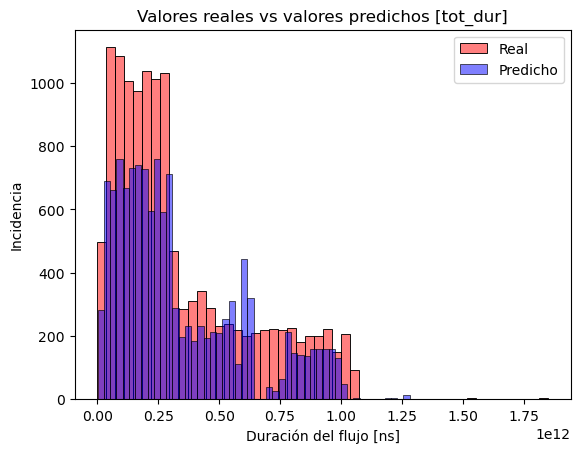

In [8]:
# grafica de valores reales y predichos
plt.title('Valores reales vs valores predichos [tot_dur]')
sns.histplot(y_val, color='red', bins=50, alpha=0.5, label='Real')
sns.histplot(y_pred, color='blue', bins=50, alpha=0.5, label='Predicho')
plt.xlabel('Duración del flujo [ns]')
plt.ylabel('Incidencia')
plt.legend()

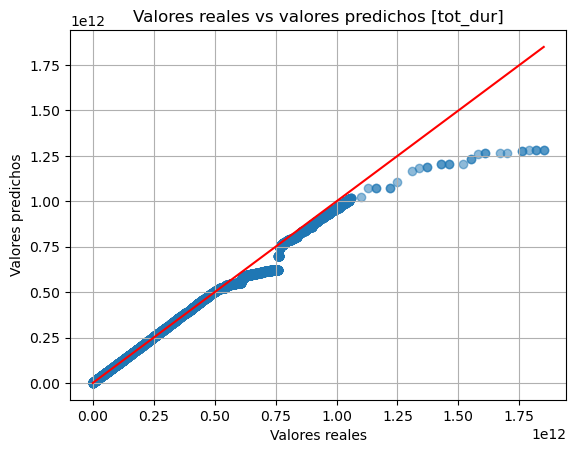

In [9]:
# grafico de dispersion de resultados
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs valores predichos [tot_dur]')
plt.grid(True)

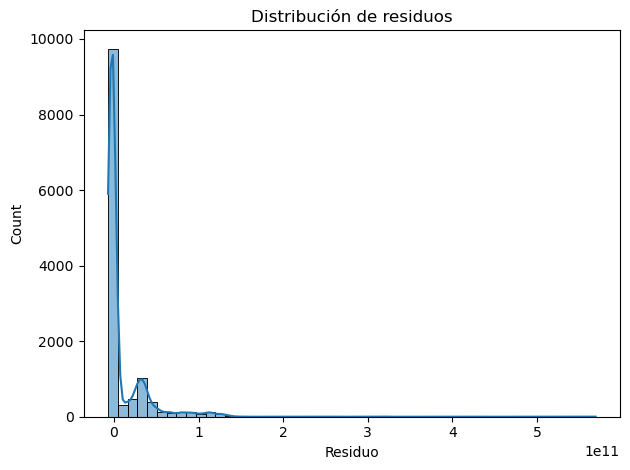

In [10]:
# grafico de residuos
residuo = y_val - y_pred

sns.histplot(residuo, bins=50, kde=True)
plt.title('Distribución de residuos')
plt.xlabel('Residuo')
plt.tight_layout()

In [11]:
# obtenemos la prediccion del modelo para datos de test
model = RandomForestRegressor(min_samples_leaf=10, random_state=10)

X_train = prepara_X(df_train)
X_val = prepara_X(df_val)
X_test = prepara_X(df_test)

model.fit(X_test, y_test)

y_pred = model.predict(X_test)

# calculo de metricas
rmse_test = rmse(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_val, y_pred)

print(f"RMSE_test: {rmse_test}")
print(f"MAE_test: {mae_test}")
print(f"R2_test: {r2_test}")

RMSE_test: 7290799594.395137
MAE_test: 563960487.7173946
R2_test: 0.9993352593537136
